In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Coombes-Byrne (Next-Generation Neural Mass)

The **Coombes-Byrne model** is a next-generation neural-mass model: an *exact* mean field of a network of theta/QIF neurons with **synaptic conductance** coupling, derived from the Ott-Antonsen reduction. Its macroscopic variables are the firing rate $r$ and mean potential $v$, with a synaptic conductance $g = k\pi r$:

$$\dot r = \tfrac{\Delta}{\pi} + 2 r v - g r,\qquad \dot v = v^2 - (\pi r)^2 + \eta + (v_{syn} - v)\,g.$$

Setting the conductance scale $k = 0$ recovers the Montbrio-Pazo-Roxin model (with $J=0$); the conductance term is what distinguishes the two synapse models.

**Reference:** Coombes & Byrne (2019), *Next generation neural mass models*, in Nonlinear Dynamics in Computational Neuroscience, Springer, pp. 1-16.

## Build the model

In [2]:
node = brainmass.CoombesByrneStep(in_size=1, Delta=1.0, eta=2.0, k=1.0, v_syn=-4.0)
node

CoombesByrneStep(
  in_size=(1,),
  out_size=(1,),
  Delta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  eta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(2., dtype=float32)
  ),
  k=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  v_syn=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-4., dtype=float32)
  ),
  init_r=Constant(value=0.1),
  init_v=Constant(value=0.0),
  method=exp_euler
)

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(80. * u.ms, monitors=['r', 'v'])
res['r'].shape

(800, 1)

## Visualize

The rate `r` and potential `v` relax toward the fixed point of the conductance-coupled mean field.

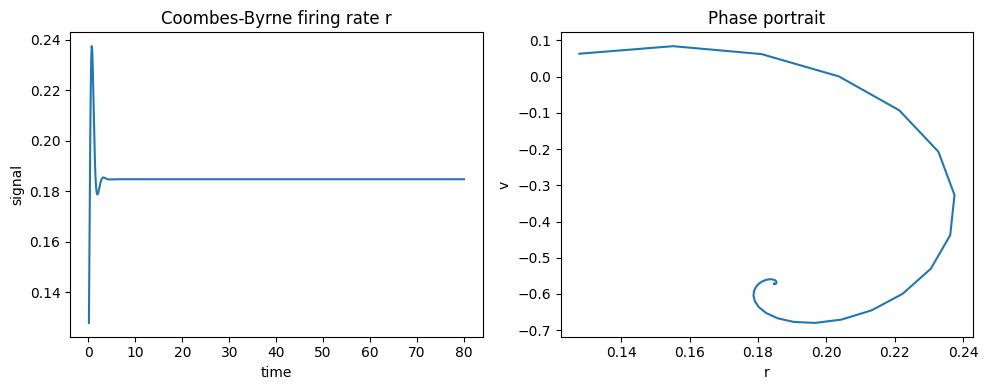

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['r'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Coombes-Byrne firing rate r')
brainmass.viz.plot_phase_portrait(res['r'], res['v'], ax=axes[1])
axes[1].set_xlabel('r'); axes[1].set_ylabel('v')
axes[1].set_title('Phase portrait')
plt.tight_layout()
plt.show()

## Try it: vary the conductance scale `k`

The synaptic conductance scale `k` is the knob that separates this model from MPR. `k = 0` removes the conductance term entirely (recovering the QIF mean field with `J = 0`); larger `k` strengthens the self-conductance and shifts the steady rate.

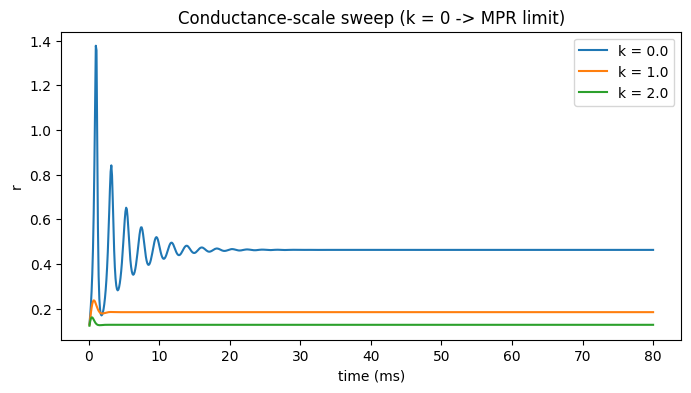

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in [0.0, 1.0, 2.0]:
    m = brainmass.CoombesByrneStep(in_size=1, Delta=1.0, eta=2.0, k=k, v_syn=-4.0)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(80. * u.ms, monitors=['r'])
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['r'])[:, 0], label=f'k = {k}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('r'); ax.legend()
ax.set_title('Conductance-scale sweep (k = 0 -> MPR limit)')
plt.show()